In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import time
import math
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error
from tensorflow.keras.optimizers import Adam
import seaborn as sns
import random
import os
from tensorflow.keras.callbacks import EarlyStopping
import joblib

In [2]:
from pathlib import Path

dataset_name = "webbrowsing_train.csv"
data_file = Path.cwd().parents[1] / "data" / "filtered" / dataset_name

df = pd.read_csv(data_file, parse_dates=["DATE"], index_col="DATE")
print("Loaded:", data_file)

Loaded: C:\Users\EJ17UF\OneDrive - Aalborg Universitet\Desktop\ms\data\filtered\webbrowsing_train.csv


In [3]:
# Set seeds for reproducibility
def set_seeds(seed=42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    tf.random.set_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

# Set the global seed to ensure reproducibility
set_seeds()

# Enable deterministic operations for TensorFlow
tf.config.experimental.enable_op_determinism()

In [4]:
target = 'mac_dl_brate'
exclude = ['mac_dl_brate', 'ue_ident']
features = [col for col in df.columns if col not in exclude]

input_steps = 5
prediction_horizon = 96

train_size = int(len(df) * 0.8)
train_df = df.iloc[:train_size]
test_df = df.iloc[train_size:]

print('Training Data',len(train_df))
print('Test Data',len(test_df))

scaler_features = MinMaxScaler()
scaler_target = MinMaxScaler()

train_features_scaled = scaler_features.fit_transform(train_df[features])
train_target_scaled = scaler_target.fit_transform(train_df[[target]])

test_features_scaled = scaler_features.transform(test_df[features])
test_target_scaled = scaler_target.transform(test_df[[target]])

def create_sequences(X_data, y_data, input_steps, prediction_horizon, original_index):
    X, y, dates = [], [], []
    for i in range(len(X_data) - input_steps - prediction_horizon + 1):
        X_seq = X_data[i:i+input_steps, :]  # Only features
        y_seq = y_data[i+input_steps:i+input_steps+prediction_horizon, 0]  # Only target
        X.append(X_seq.flatten())
        y.append(y_seq.flatten())
        dates.append(original_index[i+input_steps:i+input_steps+prediction_horizon])
    return np.array(X), np.array(y), dates

X_train_rf, y_train_rf, train_dates = create_sequences(
    train_features_scaled, train_target_scaled, input_steps, prediction_horizon, train_df.index)

X_test_rf, y_test_rf, test_dates = create_sequences(
    test_features_scaled, test_target_scaled, input_steps, prediction_horizon, test_df.index)

print('X_train_rf shape:', X_train_rf.shape)
print('y_train_rf shape:', y_train_rf.shape)
print('X_test_rf shape:', X_test_rf.shape)
print('y_test_rf shape:', y_test_rf.shape)


test_index_avg = [ts[len(ts) // 2] for ts in test_dates]

Training Data 14295
Test Data 3574


X_train_rf shape: (14195, 20)
y_train_rf shape: (14195, 96)
X_test_rf shape: (3474, 20)
y_test_rf shape: (3474, 96)


In [5]:
# XGBoost model
import xgboost as xgb
from sklearn.multioutput import MultiOutputRegressor

print('Training XGBoost Model')
xgb_basemodel = xgb.XGBRegressor(
    n_estimators=100,
    random_state=42
)

xgb_model = MultiOutputRegressor(xgb_basemodel)

xgb_model.fit(X_train_rf, y_train_rf)


Training XGBoost Model


MultiOutputRegressor(estimator=XGBRegressor(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=None, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False,
                                            eval_metric=None,
                                            feature_types=None,
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=None, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=None,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=100, n_jobs=None,
                                            num_parallel_tree=None, ...))

In [6]:
xgb_preds_scaled = xgb_model.predict(X_test_rf)

xgb_rmse = np.sqrt(mean_squared_error(y_test_rf, xgb_preds_scaled))
xgb_mae = mean_absolute_error(y_test_rf, xgb_preds_scaled)

print(f'XGBoost - scaled RMSE: {xgb_rmse:.4f}')
print(f'XGBoost - scaled MAE: {xgb_mae:.4f}')

# Average for Visualization Purpose
xgb_pred_avg = np.mean(xgb_preds_scaled, axis=1, keepdims=True)
xgb_test_avg = np.mean(y_test_rf, axis=1, keepdims=True)

xgb_pred_reshaped = scaler_target.inverse_transform(xgb_pred_avg)
xgb_test_reshaped = scaler_target.inverse_transform(xgb_test_avg)

XGBoost - scaled RMSE: 0.0758
XGBoost - scaled MAE: 0.0533


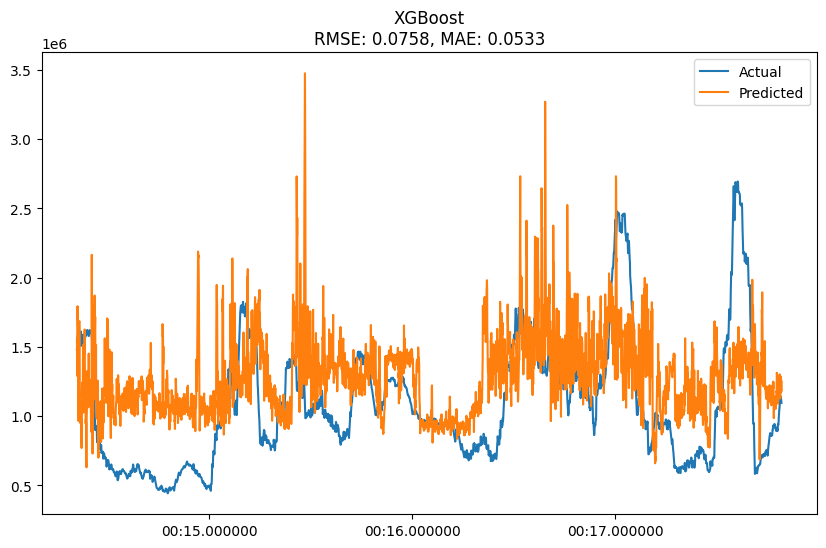

In [7]:
plt.figure(figsize=(10, 6))
plt.plot(test_index_avg, xgb_test_reshaped, label='Actual')
plt.plot(test_index_avg, xgb_pred_reshaped, label='Predicted')
plt.title(f'XGBoost\nRMSE: {xgb_rmse:.4f}, MAE: {xgb_mae:.4f}')
plt.legend()
plt.show()

In [8]:
results_dir = Path("../results/metrics/web_browsing")
results_dir.mkdir(parents=True, exist_ok=True)

metrics_df = pd.DataFrame([{
    "model": "XGB",
    "setting": "multivariate",
    "dataset": "web_browsing",
    "rmse": xgb_rmse,
    "mae": xgb_mae,
}])

metrics_file = results_dir / "xgb_multi_metrics.csv"
metrics_df.to_csv(metrics_file, index=False)

print("Saved metrics to:", metrics_file)

Saved metrics to: ..\results\metrics\web_browsing\xgb_multi_metrics.csv
